In [36]:
import os
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
import math
import numpy as np
import sirf.Gadgetron as pMR
import matplotlib.pyplot as plt


data_path = '/home/jovyan/devel/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple

# Can use either of these two as ground truth
ground_truth_with_TV = np.load(os.path.join(data_path, 'ground_truth_with_TV.npy'))
ground_truth_no_TV = np.load(os.path.join(data_path, 'ground_truth_no_TV.npy'))

Nms = 30


def rmse(input_im, ground_truth):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im), np.abs(ground_truth))
    return math.sqrt(mse)

def nrmse(input_im, ground_truth):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im), np.abs(ground_truth))
    return math.sqrt(mse) / np.max(np.abs(ground_truth))

def ssim(input_im, ground_truth):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    res_ssim = structural_similarity(np.abs(input_im), np.abs(ground_truth))
    return res_ssim


res_pdhg = {'rmse': [], 'nrmse': [], 'ssim': []}

file_pattern = r'PDHG_TV_{:02d}ms_it_{:03d}.h5'
for it in range(1,10+1):
    _fname = os.path.join(data_path, 'recons', f'MS_{Nms}', file_pattern.format(Nms, 10*it) )
    res_pdhg['rmse'].append( rmse( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    res_pdhg['nrmse'].append( nrmse( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    res_pdhg['ssim'].append( ssim( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )

res_spdhg = {'rmse': [], 'nrmse': [], 'ssim': []}
file_pattern = r'SPDHG_TV_{:02d}ms_it_{:03d}.h5'
for it in range(1,10+1):
    _fname = os.path.join(data_path, 'recons', f'MS_{Nms}', file_pattern.format(Nms, 10*it*Nms) )
    res_spdhg['rmse'].append( rmse( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    res_spdhg['nrmse'].append( nrmse( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    res_spdhg['ssim'].append( ssim( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )

e: 7
variable xml
group 2023-09-24 17:48:14
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:08:19
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:08:19
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:08:19
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:28:34
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:28:34
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:28:34
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:49:08
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:49:08
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 18:49:08
variable image_0
number of images: 1
image data type: 7
variable xml
group 2023-09-24 19:09:58
variab

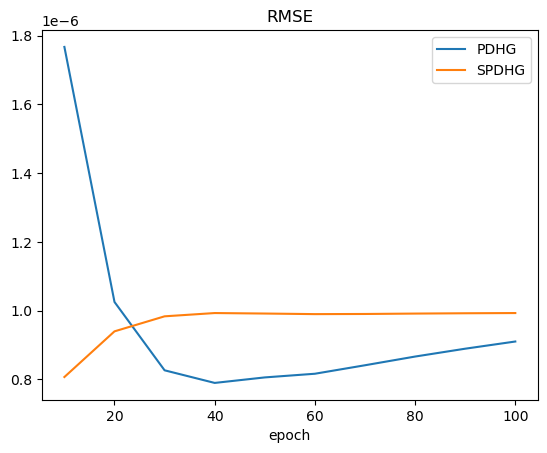

In [37]:
epochs = [it * 10 for it in range(1,11)]
plt.plot(epochs, res_pdhg['rmse'], label='PDHG' )
plt.plot(epochs, res_spdhg['rmse'], label='SPDHG' )
plt.legend()
plt.title('RMSE')
plt.xlabel('epoch')
plt.show()

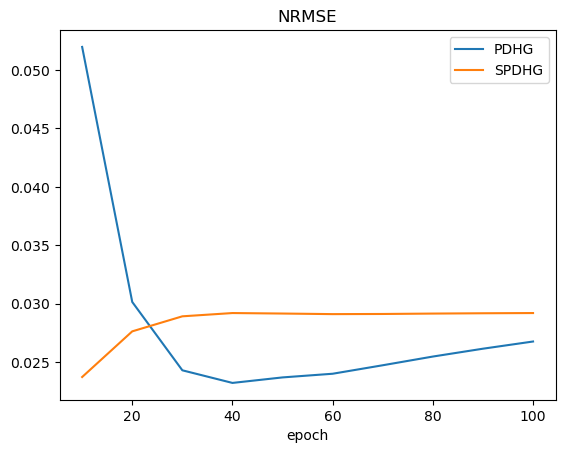

In [38]:
plt.plot(epochs, res_pdhg['nrmse'], label='PDHG' )
plt.plot(epochs, res_spdhg['nrmse'], label='SPDHG' )
plt.legend()
plt.title('NRMSE')
plt.xlabel('epoch')
plt.show()

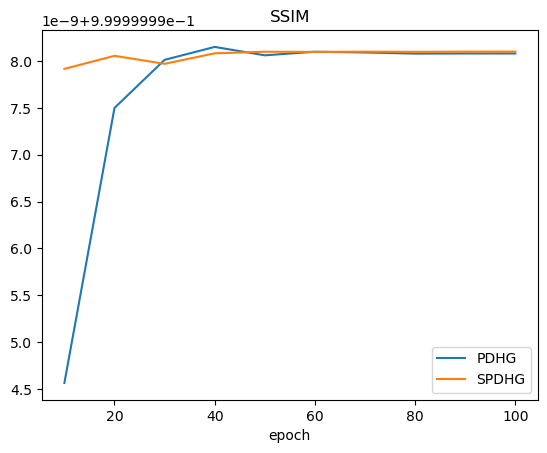

In [33]:
plt.plot(epochs, res_pdhg['ssim'], label='PDHG' )
plt.plot(epochs, res_spdhg['ssim'], label='SPDHG' )
plt.legend()
plt.title('SSIM')
plt.xlabel('epoch')
plt.show()

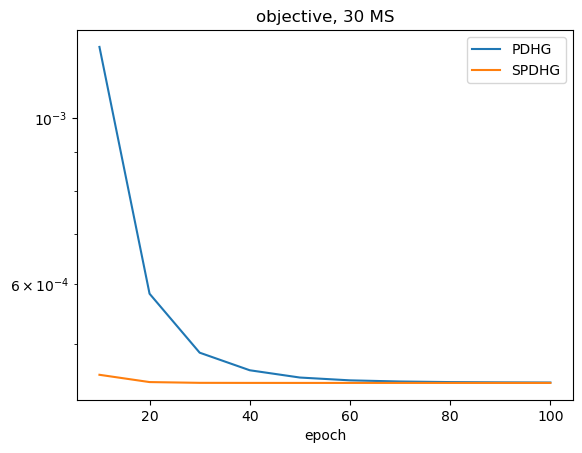

In [54]:
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}', 'SPDHG_objective.npy' )

spdhg_obj = pdhg_obj = None

if os.path.exists(_fname):
    spdhg_obj = np.load(_fname)
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}', 'PDHG_objective.npy' )
if os.path.exists(_fname):
    pdhg_obj = np.load(_fname)

if spdhg_obj is not None and pdhg_obj is not None:
    epochs0 = [it * 10 for it in range(11)]
    offset = 1
    plt.semilogy(epochs0[offset:], pdhg_obj[offset:], label='PDHG' )
    plt.semilogy(epochs0[offset:], spdhg_obj[offset:], label='SPDHG' )
    plt.legend()
    plt.title(f'objective, {Nms} MS')
    plt.xlabel('epoch')
    plt.show()



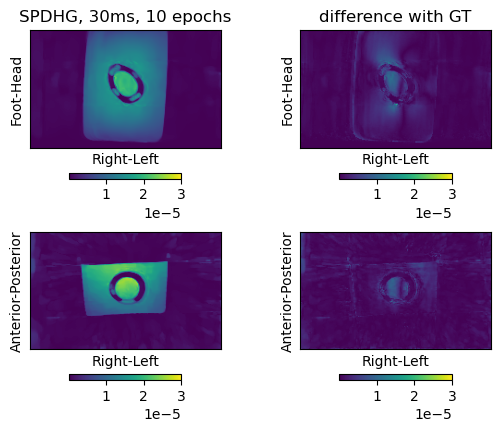

In [58]:
num_epochs = 10
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','SPDHG_TV_{}ms_it_{}.h5'.format(Nms, num_epochs*Nms) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() - ground_truth_with_TV],
            [59, 64] * 2,
            [f'SPDHG, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'SPDHG, {Nms}ms.png')

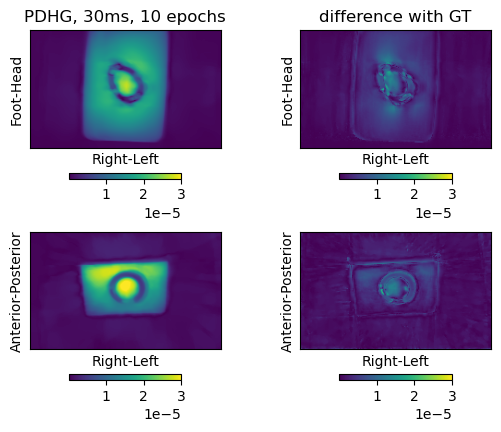

In [57]:
_fname = os.path.join(data_path, 'recons', f'MS_{Nms}','PDHG_TV_{}ms_it_{:03d}.h5'.format(Nms, num_epochs) )
im = pMR.ImageData(_fname)
plot_rpe_3d([im.as_array(), im.as_array() -ground_truth_with_TV],
            [59, 64]*2,
            [f'PDHG, {Nms}ms, {num_epochs} epochs', 'difference with GT'],
            [3*10**(-5)]*2,
            f'PDHG, {Nms}ms.png')

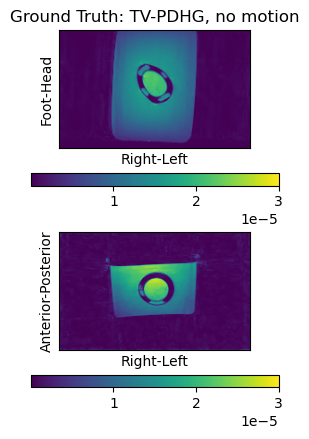

In [53]:
plot_rpe_3d([ground_truth_with_TV],
            [59, 64],
            [f'Ground Truth: TV-PDHG, no motion'],
            [3*10**(-5)],
            f'Ground-Truth PDHG, {Nms}ms.png')